In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split

We will keep adding libraries in libraries as we need them 
Now loading and cleaning the data is upto us 


In [6]:
df = pd.read_csv("used_cars_cleaned_dataset.csv")

In [7]:

print(df.sample(10))
print(f"Data types:\n{df.dtypes}\n")

print(f"Information about DataFram: {df.info()}\n")

print(df.shape)


         Car_ID       Brand      Model  Year  Mileage  Price_USD Fuel_Type  \
734   CAR_00767   Chevrolet  Silverado  2024    14899      23500  Gasoline   
2303  CAR_02399       Volvo       XC90  2015     6828      24714  Gasoline   
2099  CAR_02191        Jeep    Compass  2011    44316      15205    Diesel   
1336  CAR_01394      Jaguar     F-TYPE  2021    64961      33140  Gasoline   
2000  CAR_02090        Jeep    Compass  2007    79494       9068  Gasoline   
1982  CAR_02071  Volkswagen      Jetta  2016   104701      10821  Gasoline   
2160  CAR_02254      Subaru    Impreza  2025   128705      14501  Electric   
1193  CAR_01244      Subaru     Ascent  2002    51151       2000  Gasoline   
1080  CAR_01124         Kia  Telluride  2019    57284      18173    Diesel   
1997  CAR_02086       Volvo       XC40  2014    27411      22743    Diesel   

      Engine_Size_L  Horsepower Transmission  Num_Previous_Owners  \
734             1.7          80    Automatic                    1   
230

Brand, Model, Fuel_Type, Transmission, Color and Market_Segment came in as text, they will need to become numbers before we can model. 
also Engine_Size_L has a 0.0 minimum, that smells like a mystery, we will check it soon. 
and one more thing, there is no ready made yes/no column to predict in this dataset, we will deal with that in a bit 


In [8]:
print(f"Missing values:\n{df.isnull().sum()}\n")

Missing values:
Car_ID                     0
Brand                      0
Model                      0
Year                       0
Mileage                    0
Price_USD                  0
Fuel_Type                  0
Engine_Size_L              0
Horsepower                 0
Transmission               0
Num_Previous_Owners        0
Accident_History           0
Service_Records            0
Days_Since_Last_Service    0
Tire_Tread_Depth_mm        0
Condition_Score            0
Color                      0
Market_Segment             0
dtype: int64



In [9]:
df.describe(include='all')

,Car_ID,Brand,Model,Year,Mileage,Price_USD,Fuel_Type,Engine_Size_L,Horsepower,Transmission,Num_Previous_Owners,Accident_History,Service_Records,Days_Since_Last_Service,Tire_Tread_Depth_mm,Condition_Score,Color,Market_Segment
count,2402,2402,2402,2402.000000,2402.000000,2402.000000,2402,2402.000000,2402.000000,2402,2402.000000,2402.000000,2402.000000,2402.000000,2402.000000,2402.000000,2402,2402
unique,2402,20,100,NaN,NaN,NaN,4,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,CAR_00001,Porsche,ES,NaN,NaN,NaN,Gasoline,NaN,NaN,Automatic,NaN,NaN,NaN,NaN,NaN,NaN,Green,Economy
freq,1,140,37,NaN,NaN,NaN,1291,NaN,NaN,1838,NaN,NaN,NaN,NaN,NaN,NaN,267,1349
mean,NaN,NaN,NaN,2012.470858,49637.668609,17545.079933,NaN,2.119567,193.585346,NaN,1.480017,0.181932,7.995004,91.460033,6.434888,7.008909,NaN,NaN
std,NaN,NaN,NaN,7.445441,34600.974816,10117.548777,NaN,1.144911,152.974747,NaN,1.207629,0.385869,2.892920,90.796445,2.034312,1.541673,NaN,NaN
min,NaN,NaN,NaN,2000.000000,525.000000,2000.000000,NaN,0.000000,80.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN
25%,NaN,NaN,NaN,2006.000000,23810.750000,9872.000000,NaN,1.600000,110.250000,NaN,1.000000,0.000000,6.000000,25.000000,5.100000,6.000000,NaN,NaN
50%,NaN,NaN,NaN,2013.000000,42552.500000,16255.000000,NaN,2.300000,146.500000,NaN,1.000000,0.000000,8.000000,64.000000,6.400000,7.100000,NaN,NaN
75%,NaN,NaN,NaN,2019.000000,67061.750000,23627.000000,NaN,2.900000,194.000000,NaN,2.000000,0.000000,10.000000,126.750000,7.800000,8.100000,NaN,NaN


No missing values anywhere, nice. 
but describe shows the mystery: Engine_Size_L min is 0.0, an engine of size zero makes no sense for a car. 
also notice Price goes from 2000 all the way to 50405 USD, big range. 
lets look at the text columns with value_counts 


In [10]:
print(df['Fuel_Type'].value_counts())
print()
print(df['Transmission'].value_counts())
print()
print(df['Market_Segment'].value_counts())


Fuel_Type
Gasoline    1291
Diesel       380
Electric     374
Hybrid       357
Name: count, dtype: int64

Transmission
Automatic    1838
CVT           290
Manual        274
Name: count, dtype: int64

Market_Segment
Economy      1349
Mid-Range     886
Premium       167
Name: count, dtype: int64


Now the engine mystery. Engine_Size_L of 0.0 on a car makes no sense... 
unless the car is Electric and simply has no engine at all 


In [11]:
df[df['Engine_Size_L']==0]['Fuel_Type'].value_counts()

Fuel_Type
Electric    362
Gasoline      3
Diesel        2
Name: count, dtype: int64

Mystery solved. almost all the 0.0 engines are Electric cars, no engine, duh. 
a few Gasoline and Diesel cars show 0.0 too, probably missing values that someone filled with 0, we leave them as they are 


One problem: this dataset has no ready yes/no target like Heart_Disease or Churn. 
so we make our own question: is this car Expensive or Budget? 
rule: anything priced above the median price (16255 USD) is Expensive (1), below is Budget (0) 
VERY important: because we built the target FROM Price_USD, that column can NEVER be used as a feature later, that would be cheating (leakage). remember this, it will come back 


In [12]:
df['Expensive'] = (df['Price_USD'] > df['Price_USD'].median()).astype(int)
print(df['Expensive'].value_counts())


Expensive
1    1201
0    1201
Name: count, dtype: int64


1201 vs 1201, perfectly balanced classes this time, no imbalance problem like churn had 


In [13]:
print(df['Brand'].value_counts())
print()
print(df['Color'].value_counts())


Brand
Porsche       140
Lexus         137
Jeep          137
Ford          129
Volvo         128
BMW           127
Volkswagen    125
Chevrolet     121
Hyundai       121
Subaru        121
Tesla         120
Land Rover    119
Honda         117
Mercedes      117
Nissan        115
Audi          115
Toyota        110
Mazda         104
Kia           103
Jaguar         96
Name: count, dtype: int64

Color
Green     267
Orange    266
Silver    256
Red       248
Gray      243
Black     243
Blue      228
Yellow    224
White     216
Brown     211
Name: count, dtype: int64


Now the text columns need to become numbers: Brand, Fuel_Type, Transmission, Color and Market_Segment. 
we will use the .astype('category').cat.codes trick, it gives every category its own number 
fair warning: the numbers are just alphabetical order, the method does not know Premium is better than Economy. 
lucky for us Market_Segment alphabetical order (Economy, Mid-Range, Premium) happens to match the real price order 


In [14]:
df['Brand'] = df['Brand'].astype('category').cat.codes
df['Fuel_Type'] = df['Fuel_Type'].astype('category').cat.codes
df['Transmission'] = df['Transmission'].astype('category').cat.codes
df['Color'] = df['Color'].astype('category').cat.codes
df['Market_Segment'] = df['Market_Segment'].astype('category').cat.codes

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2402 entries, 0 to 2401
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Car_ID                   2402 non-null   str    
 1   Brand                    2402 non-null   int8   
 2   Model                    2402 non-null   str    
 3   Year                     2402 non-null   int64  
 4   Mileage                  2402 non-null   int64  
 5   Price_USD                2402 non-null   int64  
 6   Fuel_Type                2402 non-null   int8   
 7   Engine_Size_L            2402 non-null   float64
 8   Horsepower               2402 non-null   int64  
 9   Transmission             2402 non-null   int8   
 10  Num_Previous_Owners      2402 non-null   int64  
 11  Accident_History         2402 non-null   int64  
 12  Service_Records          2402 non-null   int64  
 13  Days_Since_Last_Service  2402 non-null   int64  
 14  Tire_Tread_Depth_mm      2402 non-n

We dont need Car_ID in our Model because thats only good for identification and other Related Activities but in Model Training thats no use. 
and Model has 100 unique values on 2402 rows, that is almost an ID too, so it goes as well 


In [15]:
try:
    df = df.drop(columns= ['Car_ID', 'Model'])
    df = df.dropna()
except KeyError:
    print("One of the drop columns does not exist in the DataFrame.")
    print("Proceeding without dropping it.")
print(df.info())
print(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 2402 entries, 0 to 2401
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Brand                    2402 non-null   int8   
 1   Year                     2402 non-null   int64  
 2   Mileage                  2402 non-null   int64  
 3   Price_USD                2402 non-null   int64  
 4   Fuel_Type                2402 non-null   int8   
 5   Engine_Size_L            2402 non-null   float64
 6   Horsepower               2402 non-null   int64  
 7   Transmission             2402 non-null   int8   
 8   Num_Previous_Owners      2402 non-null   int64  
 9   Accident_History         2402 non-null   int64  
 10  Service_Records          2402 non-null   int64  
 11  Days_Since_Last_Service  2402 non-null   int64  
 12  Tire_Tread_Depth_mm      2402 non-null   float64
 13  Condition_Score          2402 non-null   float64
 14  Color                    2402 non-n

In [16]:
# print(f"Missing Records : {df['Mileage'].isnull().sum()}")
# df['Mileage']= df['Mileage'].fillna(df['Mileage'].median())
# print(f"Missing Records : {df['Mileage'].isnull().sum()}")


In [17]:
# Price_USD is dropped on purpose: our target was BUILT from it,
# leaving it in would leak the answer straight into the model (cheating!)
X = df.drop(columns=['Expensive', 'Price_USD'])
X


,Brand,Year,Mileage,Fuel_Type,Engine_Size_L,Horsepower,Transmission,Num_Previous_Owners,Accident_History,Service_Records,Days_Since_Last_Service,Tire_Tread_Depth_mm,Condition_Score,Color,Market_Segment
0,10,2018,29325,0,2.1,159,0,1,0,6,56,6.5,6.7,8,2
1,3,2006,150629,2,3.5,209,0,1,0,13,256,5.9,6.0,3,0
2,3,2018,35561,3,2.3,133,0,3,0,12,191,3.6,7.7,7,0
3,2,2024,44188,2,1.8,111,0,0,1,7,11,8.4,9.7,8,1
4,14,2014,60022,0,2.4,160,0,2,1,6,12,8.2,5.8,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2397,19,2022,49832,2,2.3,104,0,3,1,7,114,4.8,5.8,0,1
2398,14,2008,39470,1,0.0,567,0,1,0,10,62,7.3,7.4,3,0
2399,7,2004,18281,2,1.5,98,0,2,1,11,131,5.1,7.2,5,0
2400,12,2004,34572,2,1.7,99,0,0,0,10,107,7.9,7.0,1,0


In [18]:
y = df['Expensive']
y


0       1
1       0
2       0
3       1
4       1
       ..
2397    1
2398    0
2399    0
2400    0
2401    1
Name: Expensive, Length: 2402, dtype: int64

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.34,random_state=42)
X_train


,Brand,Year,Mileage,Fuel_Type,Engine_Size_L,Horsepower,Transmission,Num_Previous_Owners,Accident_History,Service_Records,Days_Since_Last_Service,Tire_Tread_Depth_mm,Condition_Score,Color,Market_Segment
748,4,2023,49766,1,0.0,773,0,1,0,8,123,8.2,5.5,9,1
819,15,2016,175418,2,1.7,80,1,2,0,6,29,9.9,5.8,6,0
2003,15,2024,63169,2,2.8,147,0,0,0,7,204,5.9,5.0,0,1
567,7,2017,34932,3,1.1,80,0,5,1,5,134,6.7,7.3,7,0
856,2,2006,82485,1,0.0,643,0,4,1,14,19,3.3,3.9,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,2,2002,132671,0,3.1,215,0,2,0,8,69,4.7,8.0,4,0
1095,4,2015,101118,3,2.9,187,0,1,0,8,35,6.0,6.2,5,0
1130,4,2012,125808,2,1.6,80,0,1,0,7,94,7.0,6.3,4,0
1294,5,2010,38450,2,2.4,118,0,1,0,5,119,6.9,8.1,5,0


In [20]:
X_test

,Brand,Year,Mileage,Fuel_Type,Engine_Size_L,Horsepower,Transmission,Num_Previous_Owners,Accident_History,Service_Records,Days_Since_Last_Service,Tire_Tread_Depth_mm,Condition_Score,Color,Market_Segment
685,2,2021,77857,1,0.0,785,2,1,0,12,84,8.6,6.9,8,0
111,11,2009,65888,1,0.0,705,0,1,0,11,78,4.1,6.5,8,0
1512,7,2017,17401,2,3.6,183,1,1,0,12,203,6.2,8.9,0,0
1651,1,2011,44980,2,3.6,239,0,1,0,8,35,8.3,8.7,9,1
741,0,2006,28512,2,2.9,160,0,3,0,8,10,8.3,4.8,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1984,17,2007,24309,2,2.5,141,0,2,0,7,104,10.2,6.4,9,0
2058,7,2000,183656,2,2.2,157,0,1,0,13,165,7.8,7.4,9,0
869,12,2019,77751,2,1.8,101,1,2,1,6,161,7.3,8.0,2,2
261,19,2023,50457,2,2.1,140,1,1,0,10,207,4.2,6.8,1,1


As you can see some of our data is extremely big like Mileage going upto 230000 and some are just true and false like Expensive at 0 and 1s so we have some very overpowering features. 
we have to set them on a scale so nothing becomes overpowered 
we will use a standard scaler for that 


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #Rule of Thumb Always fit_transform on Training and transform on testing data
X_test_scaled = scaler.transform(X_test)


In [22]:
X_train_scaled

array([[-0.97022883,  1.40473676,  0.01481912, ..., -0.95530689,
         1.59001109,  0.78684866],
       [ 0.92745343,  0.46152965,  3.68544655, ..., -0.76253468,
         0.53481183, -0.82238377],
       [ 0.92745343,  1.53948063,  0.40635622, ..., -1.2765939 ,
        -1.57558671,  0.78684866],
       ...,
       [-0.97022883, -0.07744585,  2.23620717, ..., -0.44124767,
        -0.16865435, -0.82238377],
       [-0.79771226, -0.34693359, -0.31575118, ...,  0.71538556,
         0.18307874, -0.82238377],
       [-0.79771226,  0.05729803,  0.03243435, ...,  1.22944478,
        -0.16865435, -0.82238377]], shape=(1585, 15))

In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0).fit(X_train_scaled,y_train)
print(model.predict(X_train_scaled))
print(f"Training Accuracy: {model.score(X_train_scaled,y_train):.2%}")


[1 0 1 ... 0 0 0]
Training Accuracy: 94.64%


In [24]:
print(model.predict(X_test_scaled))
print(f"Testing Accuracy: {model.score(X_test_scaled,y_test):.2%}")


[0 0 0 1 0 1 0 1 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0
 0 0 1 0 1 0 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 1 1
 1 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 1
 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 1
 1 1 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 1 0 1 1 0 0 0 1 1 1 1 0 1 0 0 1 0 1 0
 1 1 1 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 1
 1 1 1 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0
 0 0 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 1 1
 1 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1
 0 0 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 1 1
 0 0 0 1 0 1 0 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1
 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 0
 1 0 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 1 1 0
 0 0 1 1 0 1 1 0 1 1 0 0 

Good news this time: our classes are perfectly balanced (50/50) so accuracy is actually trustworthy here, unlike churn. 
still we will draw the confusion matrix and ROC below, because accuracy alone never tells the full story 


In [25]:
model1 = LogisticRegression(random_state=0,
C=1,
fit_intercept=True,
).fit(X_train_scaled,y_train)


In [26]:
y_pred = model1.predict(X_test_scaled)
print(y_pred)
print(f"Model Training Data Accuracy: {model1.score(X_train_scaled,y_train):.2%}")


[0 0 0 1 0 1 0 1 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0
 0 0 1 0 1 0 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 1 1
 1 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 1
 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 1
 1 1 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 1 0 1 1 0 0 0 1 1 1 1 0 1 0 0 1 0 1 0
 1 1 1 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 1
 1 1 1 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0
 0 0 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 1 1
 1 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1
 0 0 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 1 1
 0 0 0 1 0 1 0 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1
 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 0
 1 0 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 1 1 0
 0 0 1 1 0 1 1 0 1 1 0 0 

In [27]:
print(f"model1 Testing Accuracy: {model1.score(X_test_scaled,y_test):.2%}")


model1 Testing Accuracy: 93.64%


In [28]:
modeln=LogisticRegression(random_state=9,C=1,fit_intercept=True).fit(X_train,y_train)
yn_pred = modeln.predict(X_test)
print(f"Modeln Training Accuracy: {modeln.score(X_train,y_train):.2%}",f"Modeln Testing Accuracy: {modeln.score(X_test,y_test):.2%}")
print(f"Model Training Accuracy: {model1.score(X_train_scaled,y_train):.2%}",f"Model Testing Accuracy: {model1.score(X_test_scaled,y_test):.2%}")


Modeln Training Accuracy: 60.19% Modeln Testing Accuracy: 55.08%
Model Training Accuracy: 94.64% Model Testing Accuracy: 93.64%


/Users/macbookair/Desktop/ML/VE/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Did you see that orange ConvergenceWarning on the unscaled model? thats not a coincidence. 
unscaled Mileage values in the hundreds of thousands make the solver struggle and the model scored only around 55%, barely better than a coin flip. 
the scaled model got 93%+ on the exact same data. if you ever needed proof that scaling matters, here it is 


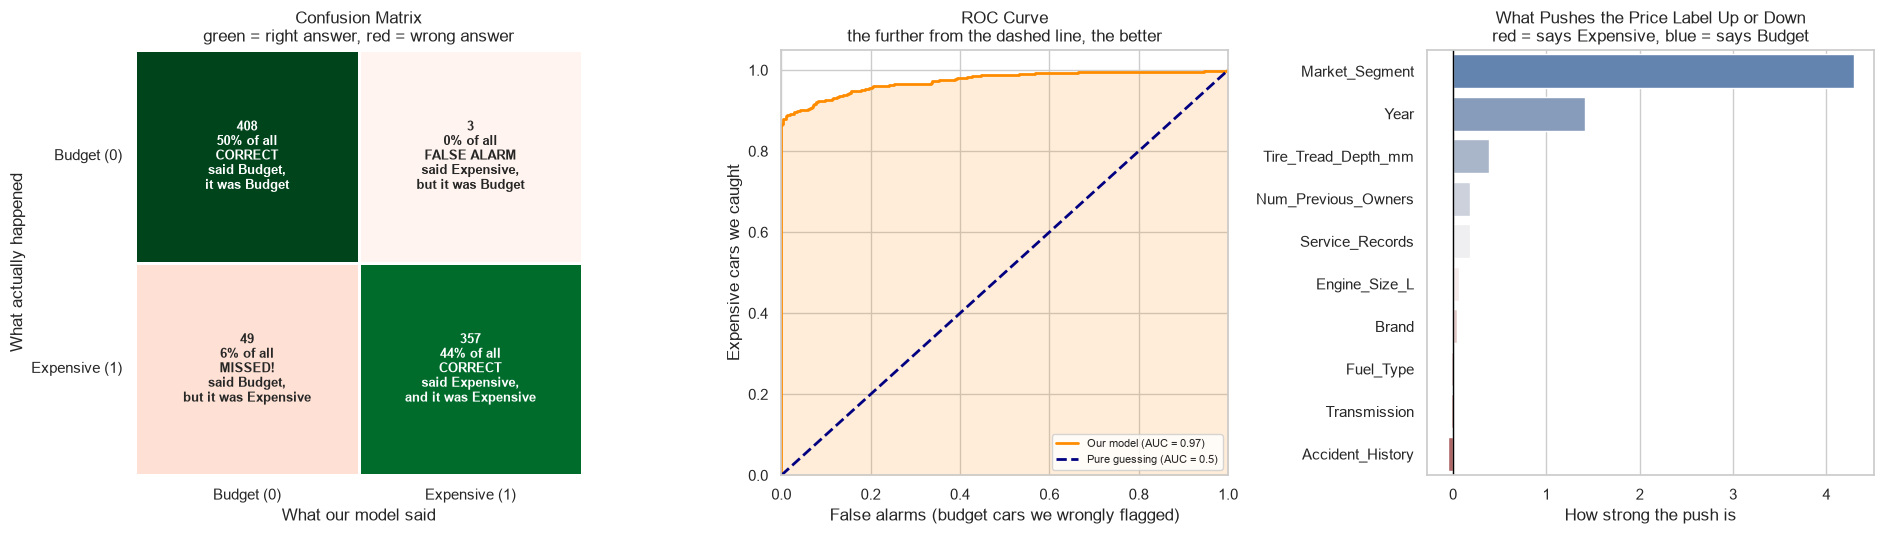

In [29]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Set seaborn style for clean visuals
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# ---------------------------------------------------------
# 1. Confusion Matrix  (green = we were right, red = we were wrong)
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
total = cm.sum()

# every square gets plain words: the count, its share, and what it means
meanings = [
    "CORRECT\nsaid Budget,\nit was Budget",
    "FALSE ALARM\nsaid Expensive,\nbut it was Budget",
    "MISSED!\nsaid Budget,\nbut it was Expensive",
    "CORRECT\nsaid Expensive,\nand it was Expensive",
]
counts = [f"{v}" for v in cm.flatten()]
shares = [f"{v/total:.0%} of all" for v in cm.flatten()]
cell_labels = np.array([f"{c}\n{s}\n{m}" for c, s, m in zip(counts, shares, meanings)]).reshape(2, 2)

# paint the diagonal (right answers) green and the mistakes red
wrong_mask = np.array([[False, True], [True, False]])   # True = hide this cell
right_mask = ~wrong_mask

sns.heatmap(cm, mask=wrong_mask, annot=cell_labels, fmt='', cmap='Greens',
            vmin=0, vmax=cm.max(), cbar=False, ax=axes[0],
            linewidths=2, linecolor='white', annot_kws={'fontsize': 9, 'fontweight': 'bold'})
sns.heatmap(cm, mask=right_mask, annot=cell_labels, fmt='', cmap='Reds',
            vmin=0, vmax=cm.max(), cbar=False, ax=axes[0],
            linewidths=2, linecolor='white', annot_kws={'fontsize': 9, 'fontweight': 'bold'})

axes[0].set_xticklabels(['Budget (0)', 'Expensive (1)'])
axes[0].set_yticklabels(['Budget (0)', 'Expensive (1)'], rotation=0)
axes[0].set_xlabel('What our model said')
axes[0].set_ylabel('What actually happened')
axes[0].set_title('Confusion Matrix\ngreen = right answer, red = wrong answer')

# ---------------------------------------------------------
# 2. ROC Curve  (how well the model RANKS cars by price class)
# ---------------------------------------------------------
# Requires probability estimates:
y_probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Our model (AUC = {roc_auc:.2f})')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='darkorange')  # the shaded area IS the AUC
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Pure guessing (AUC = 0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False alarms (budget cars we wrongly flagged)')
axes[1].set_ylabel('Expensive cars we caught')
axes[1].set_title('ROC Curve\nthe further from the dashed line, the better')
axes[1].legend(loc="lower right", fontsize=8)

# ---------------------------------------------------------
# 3. Feature Importance  (what makes a car look Expensive or Budget)
# ---------------------------------------------------------
# For Logistic Regression: coefficients
importance = pd.Series(model.coef_[0], index=X_train.columns).sort_values(ascending=False)

# Take top 10 most influential features
top_importance = importance.head(10)
sns.barplot(x=top_importance.values, y=top_importance.index,
            hue=top_importance.index, palette='vlag', legend=False, ax=axes[2])
axes[2].axvline(0, color='black', lw=1)
axes[2].set_title('What Pushes the Price Label Up or Down\nred = says Expensive, blue = says Budget')
axes[2].set_xlabel('How strong the push is')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


In [30]:
pd.Series(y_test).value_counts()

Expensive
0    411
1    406
Name: count, dtype: int64

In [31]:
roc_auc

0.9733918233792384

In [32]:
# Check correlation of all features with Expensive
# see Price_USD sitting at the top? that is the leak we talked about earlier.
# it must NEVER be a feature, the answer would flow straight from it
df.corr()['Expensive'].sort_values(ascending=False)


Expensive                  1.000000
Market_Segment             0.814364
Price_USD                  0.796601
Year                       0.668168
Transmission               0.037019
Num_Previous_Owners        0.034137
Tire_Tread_Depth_mm        0.032751
Horsepower                 0.025342
Color                      0.000443
Service_Records            0.000288
Brand                     -0.013707
Accident_History          -0.016187
Condition_Score           -0.020204
Days_Since_Last_Service   -0.021615
Fuel_Type                 -0.034221
Engine_Size_L             -0.039934
Mileage                   -0.117590
Name: Expensive, dtype: float64

In [33]:
# Example: Drop the two strongest signals (Market_Segment + Year) to make classification harder
X_harder = df.drop(columns=['Expensive', 'Price_USD', 'Market_Segment', 'Year'])

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_harder, y, test_size=0.34, random_state=42
)

scaler_h = StandardScaler()
X_train_scaled_h = scaler_h.fit_transform(X_train_h)
X_test_scaled_h = scaler_h.transform(X_test_h)

model_harder = LogisticRegression(random_state=0).fit(X_train_scaled_h, y_train_h)

print(f"Training Accuracy: {model_harder.score(X_train_scaled_h, y_train_h):.2%}")
print(f"Testing Accuracy: {model_harder.score(X_test_scaled_h, y_test_h):.2%}")


Training Accuracy: 55.71%
Testing Accuracy: 51.65%


In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"5-Fold CV Accuracy: {scores.mean():.2%} (+/- {scores.std():.2%})")


5-Fold CV Accuracy: 94.32% (+/- 1.37%)


In [35]:
# Step 1: Identify Leakage Candidates
# Print features with absolute correlation > 0.8 with the target
correlations = df.corr()['Expensive'].abs().sort_values(ascending=False)
print("Top Target Correlations:")
print(correlations[correlations > 0.8])


Top Target Correlations:
Expensive         1.000000
Market_Segment    0.814364
Name: Expensive, dtype: float64


In [36]:
# Step 2: Test Single-Feature Predictability
# If a single feature achieves near 100% accuracy, it is a target leak
from sklearn.metrics import accuracy_score

for col in df.drop(columns=['Expensive']).columns:
    acc = accuracy_score(y, df[col] > df[col].median())
    if acc > 0.85:
        print(f"Feature '{col}' alone yields {acc:.2%} accuracy (Potential Leak)")


Feature 'Price_USD' alone yields 100.00% accuracy (Potential Leak)
Feature 'Market_Segment' alone yields 93.84% accuracy (Potential Leak)


Step 2 flagged TWO features, but they are not the same thing: 
- Price_USD at 100% = a TRUE leak, we literally built the target from it, the answer flows straight from it 
- Market_Segment at ~94% = NOT a leak, it is just a genuinely strong feature. Premium cars really are expensive, no cheating involved 
thats the difference to remember: a LEAK gives the answer away for free (remove it), a STRONG FEATURE is a legitimate reason (keep it). step 3 will prove it: we drop only Price_USD and the accuracy should barely move 


In [37]:
# Step 3: Train Model Without Suspect Features
# Drop the target itself and the column we built it from (Price_USD = real leak!)
leak_cols = ['Expensive', 'Price_USD']
X_clean = df.drop(columns=leak_cols)

X_tr, X_te, y_tr, y_te = train_test_split(X_clean, y, test_size=0.34, random_state=42)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

clean_model = LogisticRegression().fit(X_tr_scaled, y_tr)
print(f"Clean Test Accuracy: {clean_model.score(X_te_scaled, y_te):.2%}")


Clean Test Accuracy: 93.64%


MODELING DONE. now the fun part, Data Analysis. lets actually LOOK at this data with seaborn diagrams and see if the pictures agree with what the model learned 


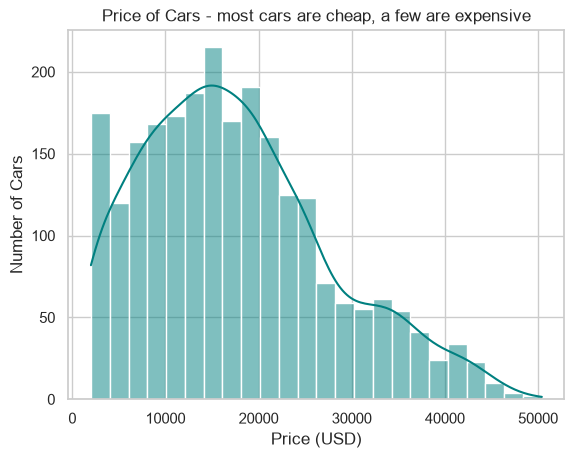

In [39]:
sns.histplot(df['Price_USD'], kde=True, color='teal')
plt.title('Price of Cars - most cars are cheap, a few are expensive')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Cars')
plt.show()


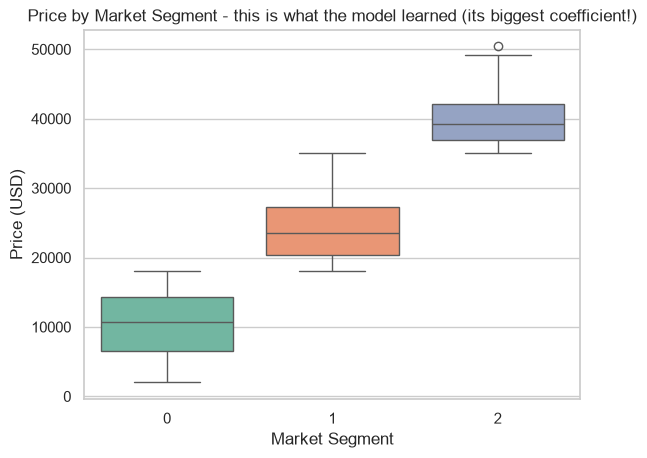

In [40]:
sns.boxplot(data=df, x='Market_Segment', y='Price_USD', hue='Market_Segment', palette='Set2', legend=False)
plt.title('Price by Market Segment - this is what the model learned (its biggest coefficient!)')
plt.xlabel('Market Segment')
plt.ylabel('Price (USD)')
plt.show()


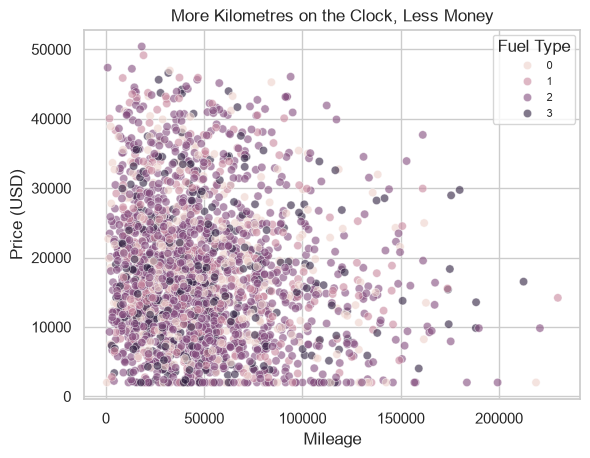

In [41]:
sns.scatterplot(data=df, x='Mileage', y='Price_USD', hue='Fuel_Type', alpha=0.6)
plt.title('More Kilometres on the Clock, Less Money')
plt.xlabel('Mileage')
plt.ylabel('Price (USD)')
plt.legend(title='Fuel Type', fontsize=8)
plt.show()


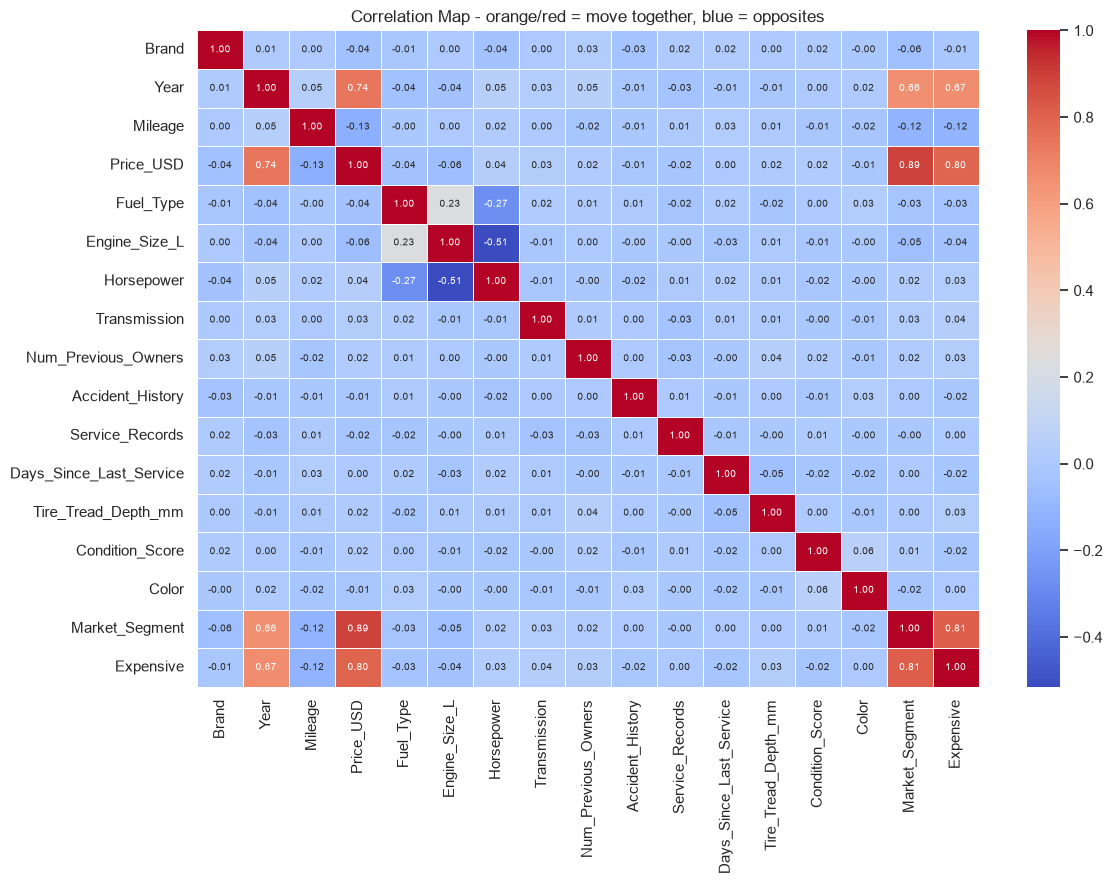

In [43]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={'fontsize': 7}, linewidths=0.5)
plt.title('Correlation Map - orange/red = move together, blue = opposites')
plt.tight_layout()
plt.show()


What the pictures told us: 
- Premium segment really is in a different price world, exactly why it was the models biggest coefficient 
- newer cars cost more and heavily used cars cost less, just like the coefficients said 
- the correlation map shows Price_USD hugging Expensive at 0.93, the leak we caught earlier staring right at us 
charts and coefficients telling the same story means the model learned something real 
